PART 03: REAL QUANTUM KERNEL CLASSIFICATION PROTOTYPE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

Tiny toy classification

In [2]:
#Sample dataset
X = np.array([
    [0.1, 0.2],
    [0.2, 0.1],
    [0.15, 0.25],
    [0.25, 0.15],
    [1.8, 1.9],
    [1.9, 1.8],
    [1.7, 1.85],
    [1.85, 1.7]
])

y = np.array([0, 0, 0, 0, 1, 1, 1, 1]) #classification -- first 4 classified as 0 and last 4 classified as 1

In [3]:
#Split the data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [7]:
n_qubits = 2
dev = qml.device('default.qubit', wires=n_qubits)

#Feature map
def phi(x):
    return 2 * (np.pi - x[0]) * (np.pi - x[1])
def havlicek_feature_map_q2_v2(x):
        qml.Hadamard(wires=0)
        qml.Hadamard(wires=1)
        qml.RZ(2 * x[0], wires=0)
        qml.RZ(2 * x[1], wires=1)
        qml.CNOT(wires=[0, 1])
        qml.RZ(phi(x), wires=1)
        qml.CNOT(wires=[0, 1])
#Circuit
@qml.qnode(dev)
def havlicek_circuit_v2(x1, x2):
    havlicek_feature_map_q2_v2(x1)
    qml.adjoint(havlicek_feature_map_q2_v2)(x2)
    return qml.probs(wires=range(n_qubits))
#kernel value
def havlicek_kernel_v2(x1, x2):
    return havlicek_circuit_v2(x1, x2)[0]
#kernel matrix
def havlicek_kernel_matrix(X):
    n = len(X)
    K = np.zeros([n, n])
    for i in range(n):
        for j in range(n):
            K[i,j] = havlicek_kernel_v2(X[i], X[j])
    return K
K = havlicek_kernel_matrix(X)
print(K)
print("Diagonals:", np.diag(K))
print("Symmetric:", np.allclose(K, K.T))

[[1.         0.98016591 0.90998223 0.89189284 0.68328216 0.66943593
  0.51292058 0.49775079]
 [0.98016591 1.         0.89189284 0.90998223 0.66943593 0.68328216
  0.49775079 0.51292058]
 [0.90998223 0.89189284 1.         0.98016591 0.41138815 0.40316311
  0.23404969 0.22729811]
 [0.89189284 0.90998223 0.98016591 1.         0.40316311 0.41138815
  0.22729811 0.23404969]
 [0.68328216 0.66943593 0.41138815 0.40316311 1.         0.98016591
  0.95001624 0.92170878]
 [0.66943593 0.68328216 0.40316311 0.41138815 0.98016591 1.
  0.92170878 0.95001624]
 [0.51292058 0.49775079 0.23404969 0.22729811 0.95001624 0.92170878
  1.         0.9558352 ]
 [0.49775079 0.51292058 0.22729811 0.23404969 0.92170878 0.95001624
  0.9558352  1.        ]]
Diagonals: [1. 1. 1. 1. 1. 1. 1. 1.]
Symmetric: True


In [8]:
#Kernel matrices
def kernel_matrix(A, B):
    K = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            K[i,j] = havlicek_kernel_v2(A[i], B[j])
    return K
K_train = kernel_matrix(X_train, X_train)
K_test = kernel_matrix(X_test, X_train)

In [10]:
#Train the SVM
clf = SVC(kernel="precomputed") #setting SVC to precomputed tells the classifier kernel already computed, you don't have to compute
clf.fit(K_train, y_train)
#Predict
y_pred = clf.predict(K_test)

print("Predictions:", y_pred)
print("true_labels:", y_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("(^v^)")

Predictions: [0 1]
true_labels: [0 1]
Accuracy: 1.0
(^v^)


In [11]:
print("K_train shape:", K_train.shape)
print(K_train)
print("K_test shape:", K_test.shape)
print(K_test)

K_train shape: (6, 6)
[[1.         0.66943593 0.98016591 0.92170878 0.68328216 0.40316311]
 [0.66943593 1.         0.68328216 0.51292058 0.98016591 0.90998223]
 [0.98016591 0.68328216 1.         0.95001624 0.66943593 0.41138815]
 [0.92170878 0.51292058 0.95001624 1.         0.49775079 0.23404969]
 [0.68328216 0.98016591 0.66943593 0.49775079 1.         0.89189284]
 [0.40316311 0.90998223 0.41138815 0.23404969 0.89189284 1.        ]]
K_test shape: (2, 6)
[[0.41138815 0.89189284 0.40316311 0.22729811 0.90998223 0.98016591]
 [0.95001624 0.49775079 0.92170878 0.9558352  0.51292058 0.22729811]]


NOTE: In the quantum kernel approach, the classifier itself is classical.
The quantum part defines the similarity measure by embedding classical inputs into quantum states and computing state overlaps.
The SVM then uses this kernel matrix to separate labeled data.

<function matplotlib.pyplot.show(close=None, block=None)>

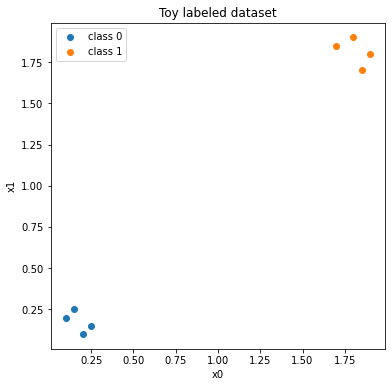

In [12]:
#Visualizing the datasets
plt.figure(figsize=(6, 6))

for label in np.unique(y):
    pts = X[y == label]
    plt.scatter(pts[:,0], pts[:,1], label=f"class {label}")
                
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Toy labeled dataset")
plt.legend()
plt.show

Classical kernel comparison

In [13]:
#Classic kernel
def classical_rbf_kernel(x1, x2, gamma=1.0):
    return np.exp(-gamma * np.linalg.norm(x1 - x2)**2)

def classical_kernel_matrix(A, B, gamma=1.0):
    K = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            K[i,j] = classical_rbf_kernel(A[i], B[j], gamma=gamma)
    return K
Kq = kernel_matrix(X, X)           #quantum
Kc = classical_kernel_matrix(X, X) #classic

print("Quantum kernel matrix:\n", Kq)
print("Classical kernel matrix:\n", Kc)

Quantum kernel matrix:
 [[1.         0.98016591 0.90998223 0.89189284 0.68328216 0.66943593
  0.51292058 0.49775079]
 [0.98016591 1.         0.89189284 0.90998223 0.66943593 0.68328216
  0.49775079 0.51292058]
 [0.90998223 0.89189284 1.         0.98016591 0.41138815 0.40316311
  0.23404969 0.22729811]
 [0.89189284 0.90998223 0.98016591 1.         0.40316311 0.41138815
  0.22729811 0.23404969]
 [0.68328216 0.66943593 0.41138815 0.40316311 1.         0.98016591
  0.95001624 0.92170878]
 [0.66943593 0.68328216 0.40316311 0.41138815 0.98016591 1.
  0.92170878 0.95001624]
 [0.51292058 0.49775079 0.23404969 0.22729811 0.95001624 0.92170878
  1.         0.9558352 ]
 [0.49775079 0.51292058 0.22729811 0.23404969 0.92170878 0.95001624
  0.9558352  1.        ]]
Classical kernel matrix:
 [[1.         0.98019867 0.99501248 0.97530991 0.00308872 0.00302755
  0.00507972 0.00492959]
 [0.98019867 1.         0.97530991 0.99501248 0.00302755 0.00308872
  0.00492959 0.00507972]
 [0.99501248 0.97530991 1. 

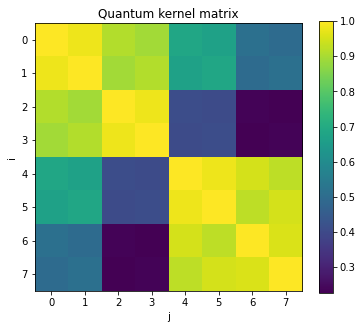

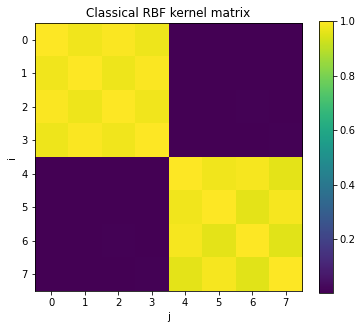

Quantum diagonal: [1. 1. 1. 1. 1. 1. 1. 1.]
Classical diagonal: [1. 1. 1. 1. 1. 1. 1. 1.]
Quantum symmetric: True
Classical symmetric: True


In [14]:
#visual comparison
plt.figure(figsize=(6, 5))
plt.imshow(Kq)
plt.colorbar()
plt.xlabel("j")
plt.ylabel("i")
plt.title("Quantum kernel matrix")
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(Kc)
plt.colorbar()
plt.xlabel("j")
plt.ylabel("i")
plt.title("Classical RBF kernel matrix")
plt.show()

print("Quantum diagonal:", np.diag(Kq))
print("Classical diagonal:", np.diag(Kc))

print("Quantum symmetric:", np.allclose(Kq, Kq.T))
print("Classical symmetric:", np.allclose(Kc, Kc.T))

In [15]:
#Training SVM with both kernels
#Quantum
Kq_train = kernel_matrix(X_train, X_train)
Kq_test = kernel_matrix(X_test, X_train)

clf_q = SVC(kernel="precomputed")
clf_q.fit(Kq_train, y_train)
y_pred_q = clf_q.predict(Kq_test)

print("Quantum predictions:", y_pred_q)
print("Quantum accuracy:", accuracy_score(y_test, y_pred_q))

#Classical
Kc_train = classical_kernel_matrix(X_train, X_train, gamma=1.0)
Kc_test = classical_kernel_matrix(X_test, X_train, gamma=1.0)

clf_c = SVC(kernel="precomputed")
clf_c.fit(Kc_train, y_train)
y_pred_c = clf_c.predict(Kc_test)

print("Classical predictions:", y_pred_c)
print("Classical accuracy:", accuracy_score(y_test, y_pred_c))

Quantum predictions: [0 1]
Quantum accuracy: 1.0
Classical predictions: [0 1]
Classical accuracy: 1.0


NOTE: Even though both kernels give same classification results we can see from kernel matrix visualizations that they uses different maps. Classical kernel is looks more flattering while quantum kernel shows more gradual similarities.
___________________________________________________________________________

Decision boundary comparison

In [16]:
#Quantum decision boundary

#Make a grind in input space
x0_min, x0_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
x1_min, x1_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3

xx, yy = np.meshgrid(
    np.linspace(x0_min, x0_max, 50), #If the cell below takes too much time decrease the point number here
    np.linspace(x1_min, x1_max, 50)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]



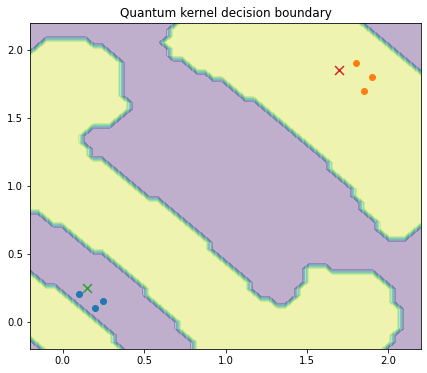

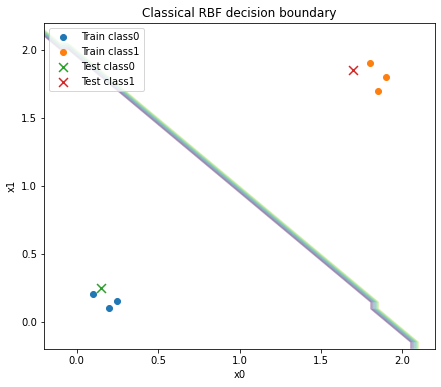

In [17]:
#Build quantum kernel between grid points and training points
K_grid_q = kernel_matrix(grid_points, X_train)

#Predict class of each point
Z_q = clf_q.predict(K_grid_q)
Z_q = Z_q.reshape(xx.shape)

#Plot
plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z_q, alpha=0.35)

for label in np.unique(y_train):
    pts = X_train[y_train == label]
    plt.scatter(pts[:,0], pts[:,1], label=f"train class{label}")
    
for label in np.unique(y_test):
    pts = X_test[y_test == label]
    plt.scatter(pts[:,0], pts[:,1], marker="x", s=80, label=f"test class{label}")
    
plt.title("Quantum kernel decision boundary")
plt.show()
#Classical kernel between grid points and training points
K_grid_c = classical_kernel_matrix(grid_points, X_train, gamma=1.0)

#predict class of each grid poits
Z_c = clf_c.predict(K_grid_c)
Z_c = Z_c.reshape(xx.shape)

#plot
plt.figure(figsize=(7,6))
plt.contour(xx, yy, Z_c, alpha=0.35)

for label in np.unique(y_train):
    pts = X_train[y_train == label]
    plt.scatter(pts[:,0], pts[:,1], label=f"Train class{label}")
    
for label in np.unique(y_test):
    pts = X_test[y_test == label]
    plt.scatter(pts[:,0], pts[:,1], marker="x", s=80, label=f"Test class{label}")

plt.title("Classical RBF decision boundary")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.show()

NOTE: Classical decition boundary looks clean, nearly linear, diagonal separating line, as expected from Euclidean closeness, while quantum decision boundary being more complex, band like. This complexity is coming from phase structure of embedding.
(i.e. phase-encoded overlaps in Hilbert space)

Different kernels induces different geometries, therefore classification performed differently.

NOTE: Quantum decision boundary takes really long time to generate. (keep in mind 50x50=2500 points are calculating). This might from calculating kernel in every point.
_____________________________________________________________

Harder dataset: two moons

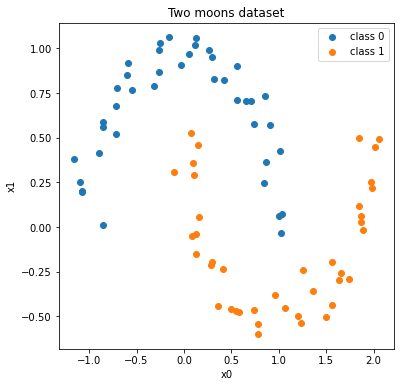

In [18]:
#Import and make dataset
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=80, noise=0.08, random_state=42)

plt.figure(figsize=(6,6))
for label in np.unique(y):
    pts = X[y == label]
    plt.scatter(pts[:, 0], pts[:, 1], label=f"class {label}")
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Two moons dataset")
plt.legend()
plt.show()

In [19]:
#split train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [20]:
#for quantum kernel I will proceed to use previously defined one
#classical baseline
def classical_rbf_kernel(x1, x2, gamma=1.0):
    return np.exp(-gamma * np.linalg.norm(x1 - x2)**2)

def classical_kernel_matrix(A, B, gamma=1.0):
    K = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            K[i,j] = classical_rbf_kernel(A[i], B[j], gamma=gamma)
    return K

#Training -- quantum
Kq_train = kernel_matrix(X_train, X_train)
Kq_test = kernel_matrix(X_test, X_train)

clf_q = SVC(kernel="precomputed")
clf_q.fit(Kq_train, y_train)
y_pred_q = clf_q.predict(Kq_test)

print("Quantum accuracy", accuracy_score(y_test, y_pred_q))

#Training -- classical
Kc_train = classical_kernel_matrix(X_train, X_train, gamma=1.0)
Kc_test = classical_kernel_matrix(X_test, X_train, gamma=1.0)

clf_c = SVC(kernel="precomputed")
clf_c.fit(Kc_train, y_train)
y_pred_c = clf_c.predict(Kc_test)

print("Classical accuracy:", accuracy_score(y_test, y_pred_c))

Quantum accuracy 0.65
Classical accuracy: 0.95


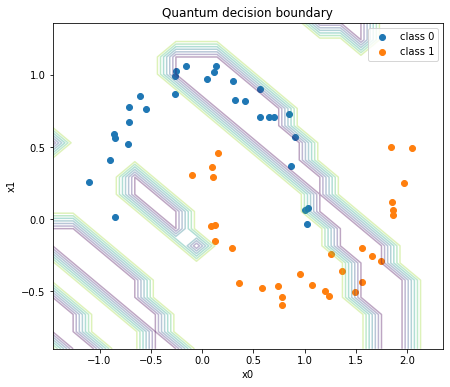

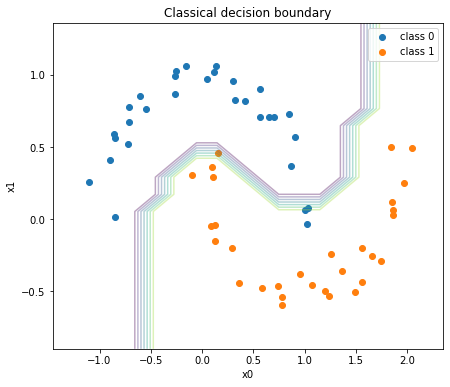

In [21]:
#Decision boundary

#grid
x0_min, x0_max = X[:,0].min() - 0.3, X[:,0].max() + 0.3
x1_min, x1_max = X[:,1].min() - 0.3, X[:,1].max() + 0.3

xx, yy = np.meshgrid(
    np.linspace(x0_min, x0_max, 20),
    np.linspace(x1_min, x1_max, 20)
)
grid_points = np.c_[xx.ravel(), yy.ravel()]

#quantum
K_grid_q = kernel_matrix(grid_points, X_train)
Z_q = clf_q.predict(K_grid_q).reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contour(xx, yy, Z_q, alpha=0.35)
for label in np.unique(y_train):
    pts = X_train[y_train == label]
    plt.scatter(pts[:,0], pts[:,1], label=f"class {label}")
plt.title("Quantum decision boundary")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.show()

#Classical
K_grid_c = classical_kernel_matrix(grid_points, X_train)
Z_q = clf_c.predict(K_grid_c).reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contour(xx, yy, Z_q, alpha=0.35)
for label in np.unique(y_train):
    pts = X_train[y_train == label]
    plt.scatter(pts[:, 0], pts[:, 1], label = f"class {label}")
plt.title("Classical decision boundary")
plt.xlabel("x0")
plt.ylabel("x1")
plt.legend()
plt.show()

Note: On the two-moons dataset classical boundary is still looks cleaner(shows supremacy), while quantum decision boundary looks mismatched. These result also reflect on the accuracies:

    Quantum accuracy 0.65
    Classical accuracy: 0.95

Conclusion: Quantum kernel is not automatically better or universally superior
Because in order to show quantum advantage the dataset should match the geometry of the featuremap.

MOS:

    1. Quantum geometry can be interesting but also badly matched
    2. Different Kernel induce different different geometries
    3. Good performance comes from feature map matching not from "quantum"

END OF THIS PART